In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/predict-survival-of-the-passengers/maritime_train.csv
/kaggle/input/competitions/predict-survival-of-the-passengers/maritime_sample_submission.csv
/kaggle/input/competitions/predict-survival-of-the-passengers/maritime_test.csv


# Importing Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, OrdinalEncoder, StandardScaler


# Load data

In [3]:
# -------------------------------------------------------
# 1) Load data
# -------------------------------------------------------
train = pd.read_csv("/kaggle/input/competitions/predict-survival-of-the-passengers/maritime_train.csv")
test = pd.read_csv("/kaggle/input/competitions/predict-survival-of-the-passengers/maritime_test.csv")
test_original = test.copy()


# Fix typo in column name CLass
def clean_columns(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    if "CLass" in df.columns and "Class" not in df.columns:
        df = df.rename(columns={"CLass": "Class"})
    return df

train = clean_columns(train)
test = clean_columns(test)

y = train["Outcome"].astype(int)
train_features = train.drop(columns=["Outcome"])


In [4]:
train.head()

,PassengerId,TicketTier,PassengerName,Gender,Age,RelativesAboard,ParentsChildren,Class,TicketCost,Berth,BoardingPort,FamilySize,Singleton,FarePerPerson,Title,Outcome
0,338.376107,0.977533,"Partner, Mr. Austen",male,NaN,0.005991,-0.024062,113043,29.104891,C124,S,1,1,25.906873,Mr,0
1,732.225160,2.016456,"Berriman, Mr. William John",male,21.574386,0.091114,-0.021340,28425,11.033567,NaN,S,1,1,10.939094,Mr,0
2,391.314100,2.998448,"Tikkanen, Mr. Juho",male,33.490756,-0.072885,-0.021702,STON/O 2. 3101293,2.234540,NaN,S,1,1,4.065968,Mr,0
3,724.550481,3.045488,"Hansen, Mr. Henrik Juul",male,25.200171,0.913680,0.032986,350025,10.958320,NaN,S,2,0,3.733784,Mr,0
4,810.994274,3.004710,"Andersson, Miss. Ebba Iris Alfrida",female,5.839590,4.009691,1.956266,347082,33.765343,NaN,S,7,0,3.325612,Miss,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      712 non-null    float64
 1   TicketTier       712 non-null    float64
 2   PassengerName    712 non-null    object 
 3   Gender           712 non-null    object 
 4   Age              515 non-null    float64
 5   RelativesAboard  712 non-null    float64
 6   ParentsChildren  712 non-null    float64
 7   Class            712 non-null    object 
 8   TicketCost       712 non-null    float64
 9   Berth            159 non-null    object 
 10  BoardingPort     710 non-null    object 
 11  FamilySize       712 non-null    int64  
 12  Singleton        712 non-null    int64  
 13  FarePerPerson    712 non-null    float64
 14  Title            712 non-null    object 
 15  Outcome          712 non-null    int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 89.1+ KB


In [6]:
#Check missing values
train.isna().sum()

PassengerId          0
TicketTier           0
PassengerName        0
Gender               0
Age                197
RelativesAboard      0
ParentsChildren      0
Class                0
TicketCost           0
Berth              553
BoardingPort         2
FamilySize           0
Singleton            0
FarePerPerson        0
Title                0
Outcome              0
dtype: int64

In [7]:
train.describe()

,PassengerId,TicketTier,Age,RelativesAboard,ParentsChildren,TicketCost,FamilySize,Singleton,FarePerPerson,Outcome
count,712.000000,712.000000,515.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,448.089668,2.333755,29.783025,0.555223,0.378523,32.456248,1.932584,0.602528,20.043894,0.376404
std,256.347351,0.826466,14.605177,1.174990,0.791899,52.079443,1.682525,0.489719,38.109959,0.484824
min,-19.969283,0.893173,-1.128370,-0.148789,-0.115958,-3.982686,1.000000,0.000000,-4.526815,0.000000
25%,222.160559,1.954529,20.666161,-0.016907,-0.020213,8.380745,1.000000,0.000000,6.596378,0.000000
50%,455.043258,2.954504,28.374231,0.040156,0.017184,14.833240,1.000000,1.000000,9.272521,0.000000
75%,671.639433,3.006993,38.707210,0.967004,0.082670,30.775352,2.000000,1.000000,18.980591,1.000000
max,905.400989,3.108531,79.849115,8.027245,6.045675,514.074158,11.000000,1.000000,512.004226,1.000000


In [8]:
train.columns

Index(['PassengerId', 'TicketTier', 'PassengerName', 'Gender', 'Age',
       'RelativesAboard', 'ParentsChildren', 'Class', 'TicketCost', 'Berth',
       'BoardingPort', 'FamilySize', 'Singleton', 'FarePerPerson', 'Title',
       'Outcome'],
      dtype='object')

# Data Preprocessing

## Imputing
### Impute `Age`
- Impute missing Age values using the average age within each Title-Gender group

In [9]:
train['Age'] = train.groupby(['Title', 'Gender'])['Age']\
              .transform(lambda x: x.fillna(x.mean()))

test['Age'] = test.groupby(['Title', 'Gender'])['Age']\
              .transform(lambda x: x.fillna(x.mean()))

### Impute `BoardingPort`
- Impute BoardingPort with mode of the feature

In [10]:
train['BoardingPort'].value_counts()
# train['BoardingPort'].unique()

BoardingPort
S    525
C    125
Q     60
Name: count, dtype: int64

In [11]:
# Impute BoardingPort with mode of the feature

train["BoardingPort"] = train["BoardingPort"].fillna(train["BoardingPort"].mode()[0])
test["BoardingPort"] = test["BoardingPort"].fillna(train["BoardingPort"].mode()[0])

## Encoding
- Encode `Title` and `BoardingPort` with OneHot Encoding

In [12]:
train['Title'].value_counts()

Title
Mr        419
Miss      146
Mrs        97
Master     33
Rare       17
Name: count, dtype: int64

In [13]:
# Title, BoardingPort encoded
train = pd.get_dummies(train, columns=["BoardingPort", "Title"], dtype=int)
test = pd.get_dummies(test, columns=["BoardingPort", "Title"], dtype=int)


## Feature Engineering 

### `Berth`
- creating new relavent features from `Berth`


In [14]:
train['Berth'].unique()

array(['C124', nan, 'B58 B60', 'B38', 'C52', 'C93', 'C45', 'B20',
       'B96 B98', 'C82', 'C78', 'C106', 'C22 C26', 'B57 B59 B63 B66',
       'B28', 'C104', 'F2', 'D11', 'C86', 'E38', 'A34', 'C91', 'C68',
       'F G73', 'E46', 'C92', 'E50', 'A32', 'G6', 'C128', 'E10', 'E44',
       'B41', 'B18', 'D35', 'E31', 'C2', 'C50', 'C103', 'B3', 'A10',
       'C49', 'C90', 'B77', 'C123', 'D', 'D36', 'E33', 'B5', 'A19', 'B37',
       'E58', 'C23 C25 C27', 'F33', 'C7', 'E67', 'E8', 'B22', 'B35',
       'C125', 'C65', 'C54', 'B80', 'B94', 'D26', 'E121', 'E24', 'D45',
       'B101', 'B51 B53 B55', 'D17', 'D46', 'E17', 'B4', 'C46', 'A23',
       'F4', 'C47', 'E101', 'C111', 'C101', 'B82 B84', 'C70', 'C32',
       'B102', 'D20', 'B71', 'A36', 'D9', 'B50', 'D33', 'A16', 'B19',
       'E12', 'C83', 'A26', 'F E69', 'A24', 'B73', 'C30', 'E40', 'D30',
       'B42', 'C99', 'C85', 'D37', 'T', 'F38', 'C118', 'B49', 'B79', 'D6',
       'F G63', 'A14', 'D49', 'C87', 'D56', 'C62 C64'], dtype=object)

In [15]:
def process_berth(df):
    df = df.copy()

    df["BerthKnown"] = df["Berth"].notna().astype(int)

    # keep missing as missing, do NOT cast the whole column to str first
    df["BerthDeck"] = df["Berth"].str.extract(r"([A-Za-z])", expand=False)
    df["BerthDeck"] = df["BerthDeck"].fillna("Missing")

    df["BerthCabinCount"] = (
        df["Berth"]
        .fillna("")
        .astype(str)
        .str.strip()
        .apply(lambda x: 0 if x == "" else len(x.split()))
    )

    df["BerthMultiCabin"] = (df["BerthCabinCount"] > 1).astype(int)

    df = df.drop(columns=["Berth"])
    return df

In [16]:
train = process_berth(train)
test = process_berth(test)

In [17]:
train = pd.get_dummies(train, columns=["BerthDeck"], dtype=int)
test = pd.get_dummies(test, columns=["BerthDeck"], dtype=int)

### `Gender`
- Mapping gender to `1, 0`
- Creating new features from `Gender`

In [18]:
gender_map = {"male": 0, "female": 1}

train["Gender"] = train["Gender"].str.lower().map(gender_map)
test["Gender"] = test["Gender"].str.lower().map(gender_map)

In [19]:
train['Child'] = (train['Age'] < 16).astype(int)
test['Child'] = (test['Age'] < 16).astype(int)

In [20]:
train['FemaleChild'] = (
    (train['Gender'] == 1) &
    (train['Age'] < 16)
).astype(int)

test['FemaleChild'] = (
    (test['Gender'] == 1) &
    (test['Age'] < 16)
).astype(int)

In [21]:
train['FirstClassFemale'] = (
    (train['Gender'] == 1) &
    (train['TicketTier'] < 1.5)
).astype(int)

test['FirstClassFemale'] = (
    (test['Gender'] == 1) &
    (test['TicketTier'] < 1.5)
).astype(int)

In [22]:
train['FamilyGroup'] = pd.cut(
    train['FamilySize'],
    bins=[0,1,4,20],
    labels=[0,1,2]
).astype(int)

test['FamilyGroup'] = pd.cut(
    test['FamilySize'],
    bins=[0,1,4,20],
    labels=[0,1,2]
).astype(int)

### `PassengerName`
- Creating new features from `PassengerName`

In [23]:
train['Surname'] = train['PassengerName'].str.split(',').str[0].str.strip()
test['Surname'] = test['PassengerName'].str.split(',').str[0].str.strip()

counts = pd.concat([
    train['Surname'],
    test['Surname']
]).value_counts()

train['SurnameCount'] = train['Surname'].map(counts)
test['SurnameCount'] = test['Surname'].map(counts)

train.drop(columns=['Surname'], inplace=True)
test.drop(columns=['Surname'], inplace=True)

In [24]:
# all_df = pd.concat([train, test])

# ticket_counts = all_df['Class'].value_counts()

# train['TicketGroupSize'] = train['Class'].map(ticket_counts)
# test['TicketGroupSize'] = test['Class'].map(ticket_counts)

# EDA
## Histogram 
- Visualizing the distribution of all features

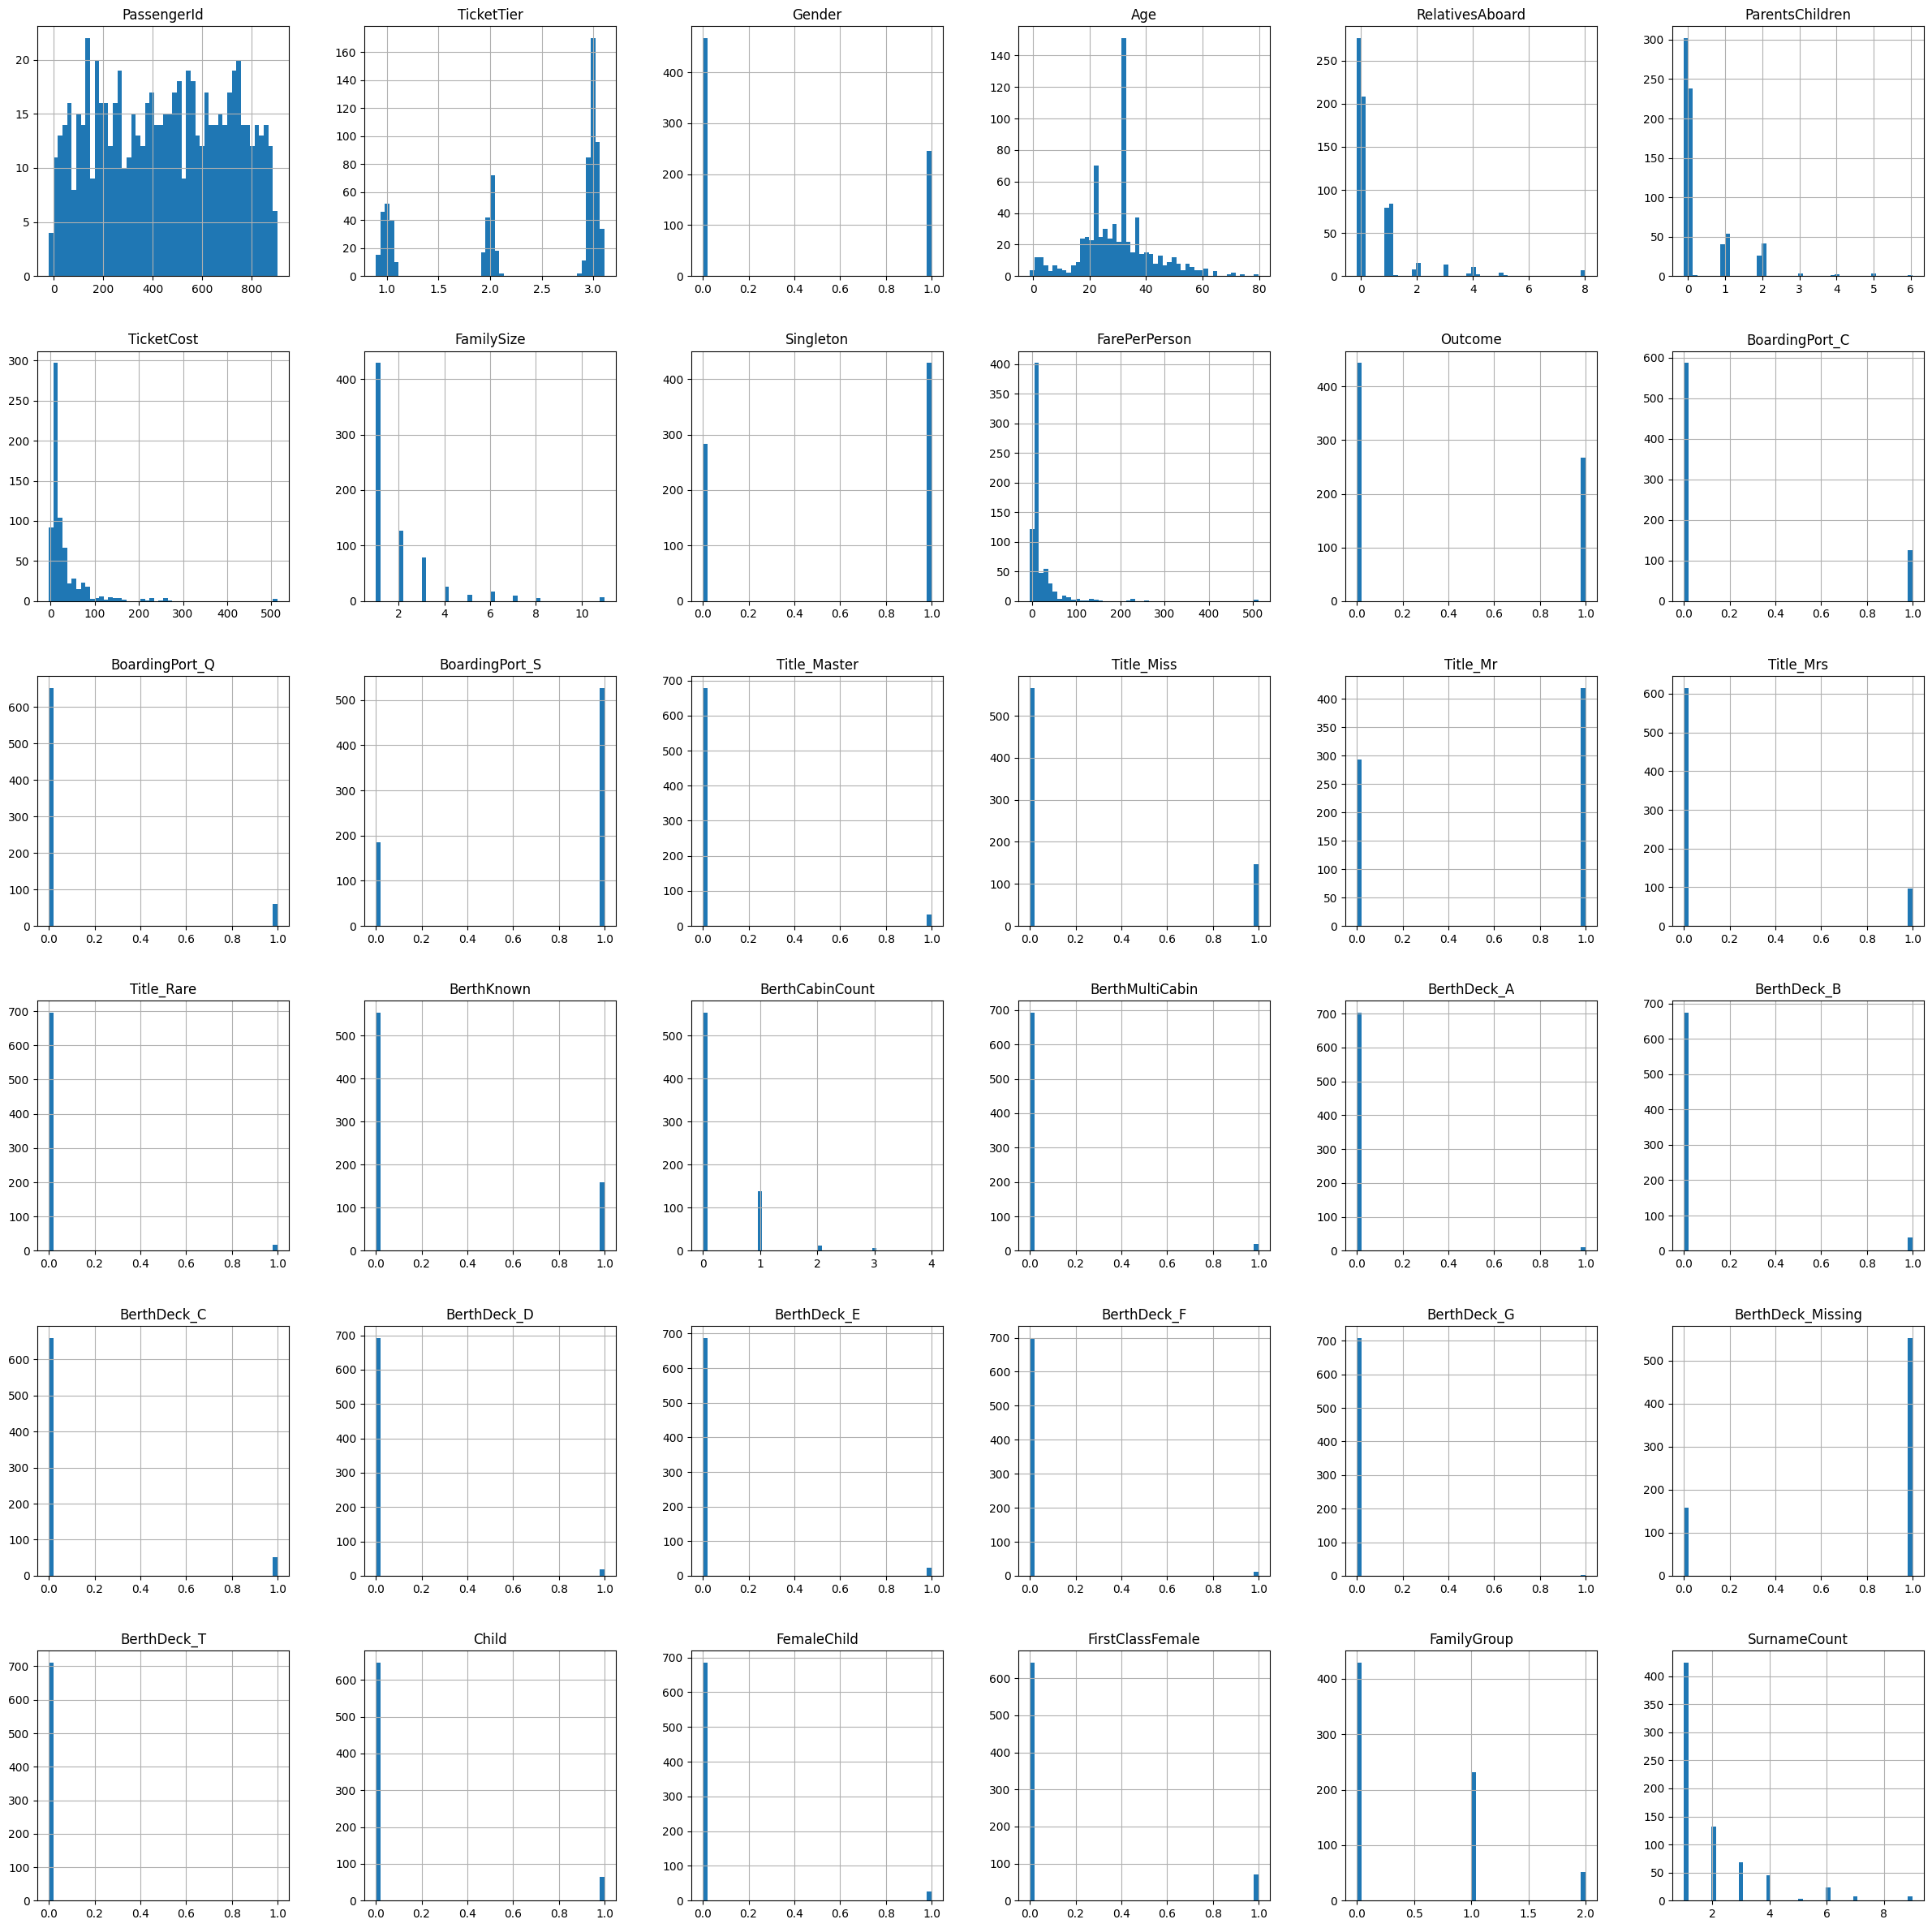

In [25]:
train.hist(bins=50, figsize=(30,30))
plt.show()

## Correlation Heatmap
- Visualizing the Correlation of the features across

<Axes: >

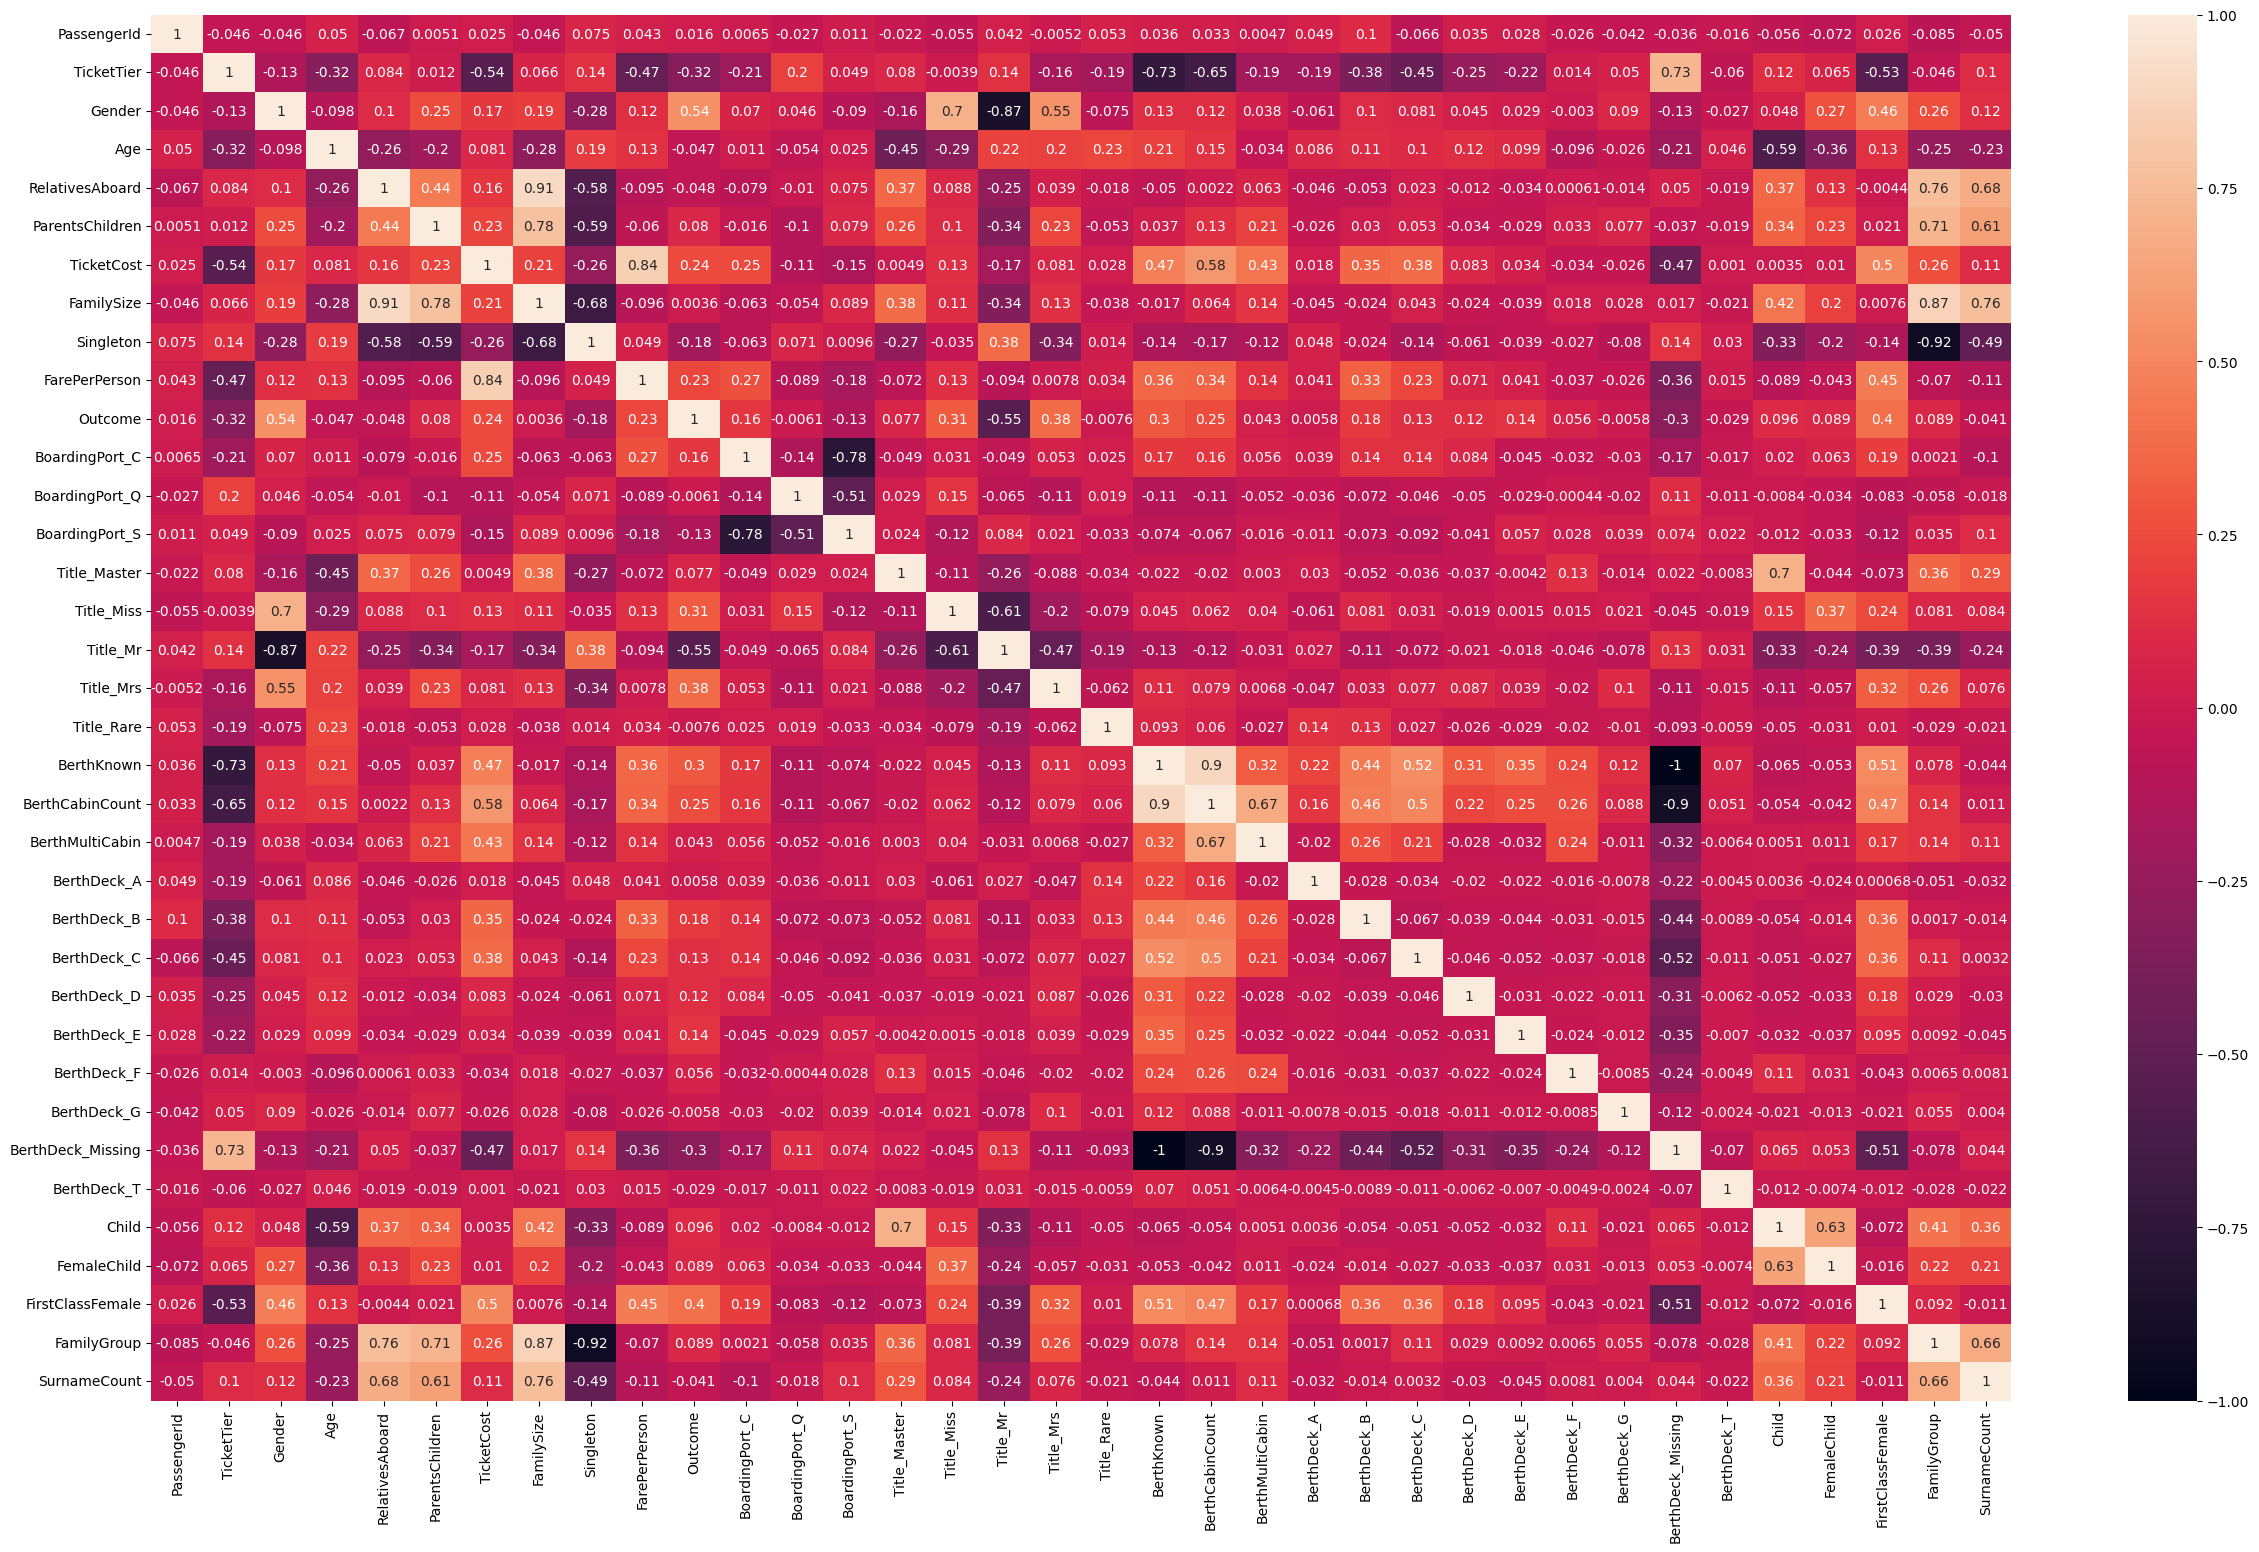

In [26]:
num_feats=train.drop(columns=['PassengerName','Class'])
corr_map=num_feats.corr()
plt.figure(figsize=(30,18))
sns.heatmap(corr_map,annot=True)

## Scatterplot
- Observing the spread of the values
- Checking for possible outliers

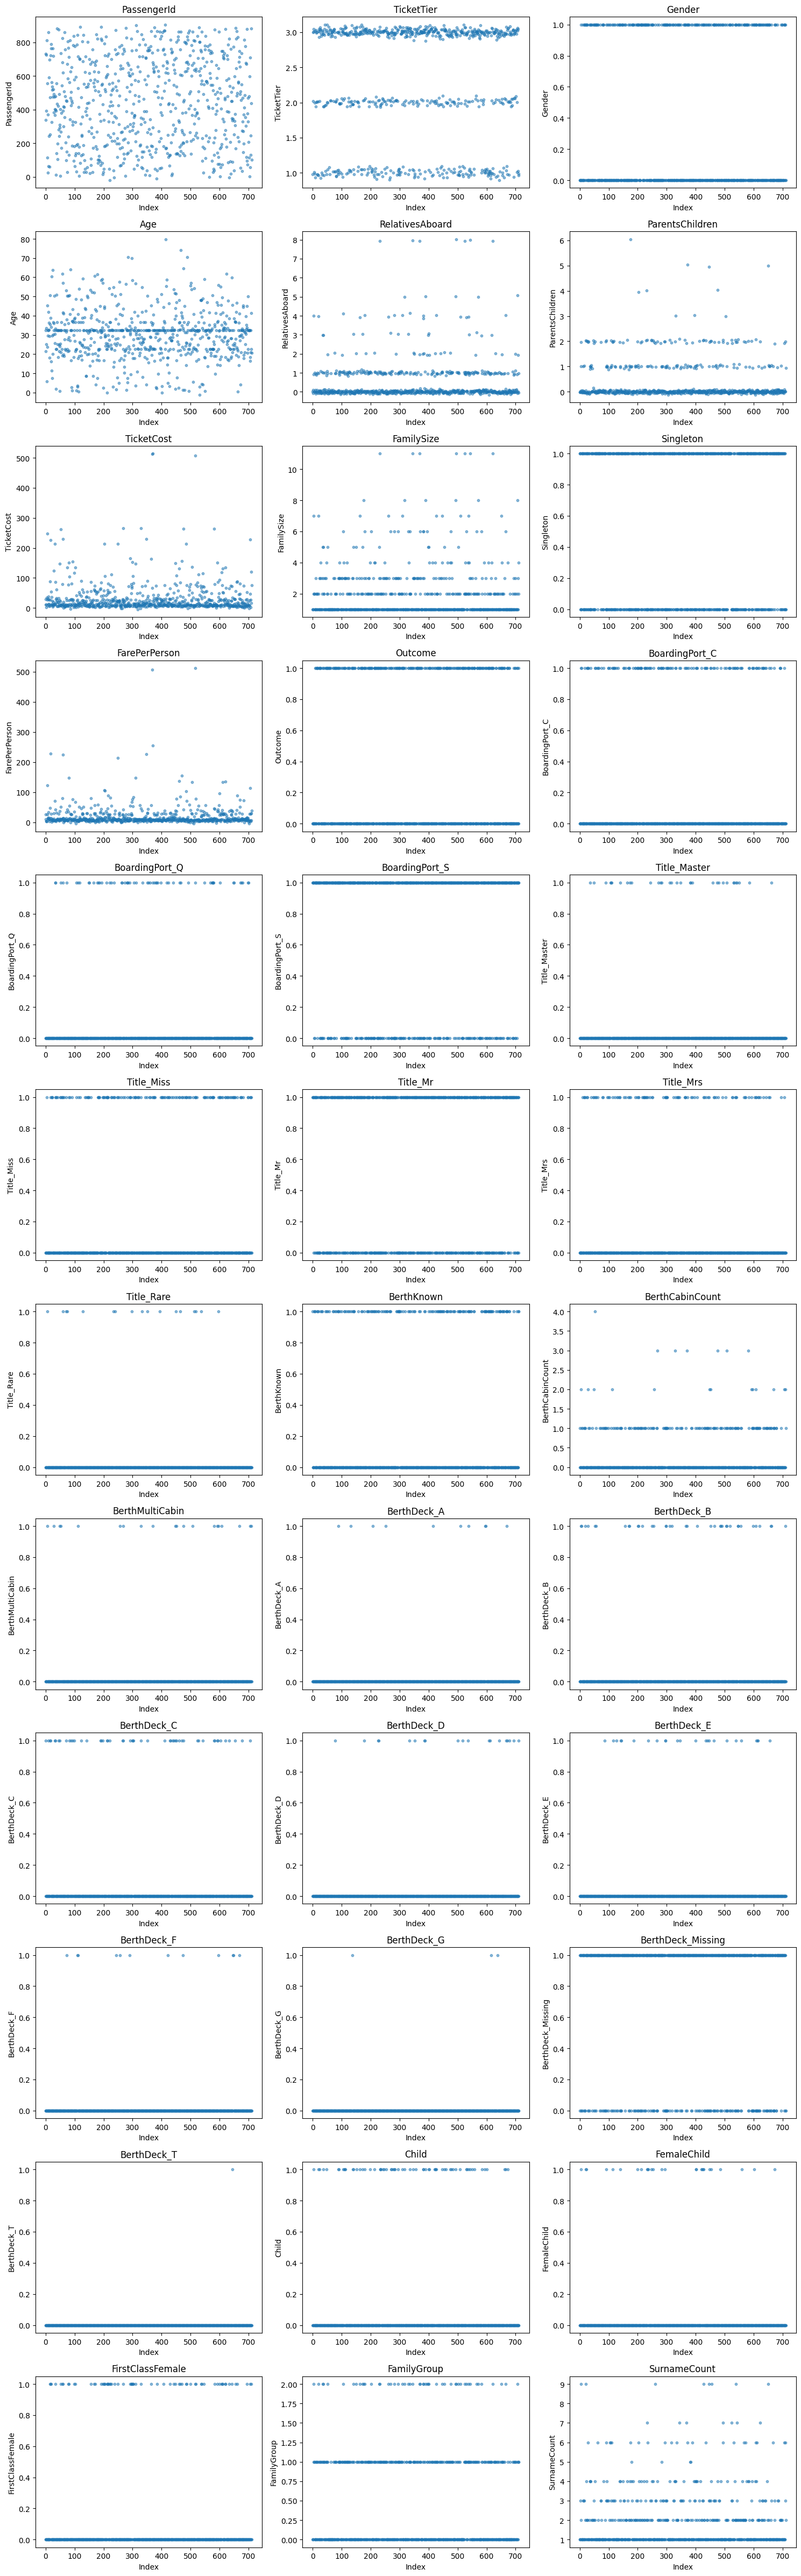

In [27]:
numeric_cols = train.select_dtypes(include=np.number).columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.scatter(train.index, train[col], alpha=0.5, s=10)
    ax.set_title(col)
    ax.set_xlabel('Index')
    ax.set_ylabel(col)

# Remove unused axes
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

# Final Dataset with all relevant features

In [28]:
drop_cols = [
    'Outcome',
    "PassengerId",
    'PassengerName',
    'BerthDeck_T',
    'Class',
    "FarePerPerson",
    "TicketGroupSize",
    "SurnameCount",
    "Child",
    "FemaleChild",
    "FamilyGroup",
    "BerthKnown",
    "BerthCabinCount",
    "BerthMultiCabin",
    "Title_Miss",
    "BoardingPort_Q",
    "RelativesAboard",
    "BoardingPort_Q"

]

X = train.drop(columns=drop_cols, errors="ignore")
y = train["Outcome"]

X.shape

(712, 22)

In [29]:
drop_cols = [
    "PassengerId",
    'PassengerName',
    'BerthDeck_T',
    'Class',
    "FarePerPerson",
    "TicketGroupSize",
    "SurnameCount",
    "Child",
    "FemaleChild",
    "FamilyGroup",
    "BerthKnown",
    "BerthCabinCount",
    "BerthMultiCabin",
    "Title_Miss",
    "BoardingPort_Q",
    "RelativesAboard",
    "BoardingPort_Q"
]

test = test.drop(columns=drop_cols, errors="ignore")

# Train Test Split

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
- Logistic Regression
- Random Forest
- Extra Trees

In [31]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    # "Random Forest": RandomForestClassifier(
    #     n_estimators=500,
    #     random_state=42,
    #     n_jobs=-1
    # ),

    # "Extra Trees": ExtraTreesClassifier(
    #     n_estimators=500,
    #     random_state=42,
    #     n_jobs=-1
    # )
}


## Fitting the models

Logistic Regression works the best, so we use it

- `Logistic Regression: 0.8811`
- `Random Forest: 0.8392`
- `Extra Trees: 0.8392`

In [32]:
# Single Train/Validation Split

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    acc = accuracy_score(y_valid, preds)

    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.8811


# Model Evaluation
## Cross-Validation

- Evaluate each model using 5-fold stratified cross-validation to estimate its accuracy and stability across different data splits
- `Logistic Regression: Mean=0.8371 Std=0.0251`
- `Random Forest: Mean=0.8118 Std=0.0289`
- `Extra Trees: Mean=0.8076 Std=0.0226`

In [33]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    print(
        f"{name}: "
        f"Mean={scores.mean():.4f} "
        f"Std={scores.std():.4f}"
    )

Logistic Regression: Mean=0.8371 Std=0.0251


In [34]:
model.fit(X, y)

LogisticRegression(max_iter=5000, random_state=42)

# Feature Importance Analysis

Extract the model coefficients, calculate their absolute magnitudes, and sort them to identify which features have the strongest influence on predictions.

In [35]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Abs"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs", ascending=False)
coef_df

,Feature,Coefficient,Abs
10,Title_Mr,-1.516040,1.516040
9,Title_Master,1.367777,1.367777
1,Gender,1.135220,1.135220
11,Title_Mrs,1.035134,1.035134
17,BerthDeck_E,0.985338,0.985338
19,BerthDeck_G,-0.788664,0.788664
12,Title_Rare,-0.740753,0.740753
16,BerthDeck_D,0.599997,0.599997
0,TicketTier,-0.590023,0.590023
21,FirstClassFemale,0.580775,0.580775


# Prediction
- Final prediction

In [36]:
# Predict test
test_preds = model.predict(test)

# Submission

In [37]:
submission = pd.DataFrame({
    "PassengerName": test_original["PassengerName"],
    "Outcome": test_preds.astype(int)
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved")
print(submission.head())

submission.csv saved
                                       PassengerName  Outcome
0  Moubarek, Master. Halim Gonios ("William George")        1
1             Kvillner, Mr. Johan Henrik Johannesson        0
2                        Alhomaki, Mr. Ilmari Rudolf        0
3                  Harper, Miss. Annie Jessie "Nina"        1
4                        Nicola-Yarred, Miss. Jamila        1
